In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [91]:
df=pd.read_csv("../data/cpu_scheduling_process.csv")
df.head()

,process_id,arrival_time,burst_time,priority,process_type,short_job,long_job,io_flag,cpu_flag,high_priority,dynamic_arrival,best_algorithm
0,P1,0,1,5,IO-bound,1,0,1,0,0,0,SJF
1,P2,20,14,9,IO-bound,0,1,1,0,1,1,Round Robin
2,P3,11,15,8,IO-bound,0,1,1,0,1,1,Priority
3,P4,4,18,7,IO-bound,0,1,1,0,1,0,Round Robin
4,P5,20,13,5,CPU-bound,0,1,0,1,0,1,Round Robin


In [92]:
df.head()

,process_id,arrival_time,burst_time,priority,process_type,short_job,long_job,io_flag,cpu_flag,high_priority,dynamic_arrival,best_algorithm
0,P1,0,1,5,IO-bound,1,0,1,0,0,0,SJF
1,P2,20,14,9,IO-bound,0,1,1,0,1,1,Round Robin
2,P3,11,15,8,IO-bound,0,1,1,0,1,1,Priority
3,P4,4,18,7,IO-bound,0,1,1,0,1,0,Round Robin
4,P5,20,13,5,CPU-bound,0,1,0,1,0,1,Round Robin


In [93]:
df.columns

Index(['process_id', 'arrival_time', 'burst_time', 'priority', 'process_type',
       'short_job', 'long_job', 'io_flag', 'cpu_flag', 'high_priority',
       'dynamic_arrival', 'best_algorithm'],
      dtype='object')

In [94]:
df.drop('process_id', axis=1, inplace=True)

<Axes: xlabel='process_type'>

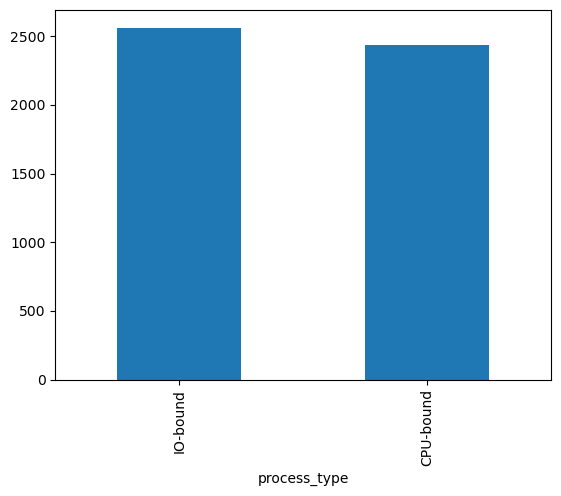

In [95]:
df['process_type'].value_counts().plot(kind='bar')

In [96]:
categorical_cols = []
numerical_cols = []
for col in df.columns:
    if df[col].dtype == 'object':
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

In [97]:
categorical_cols

['process_type', 'best_algorithm']

<Axes: >

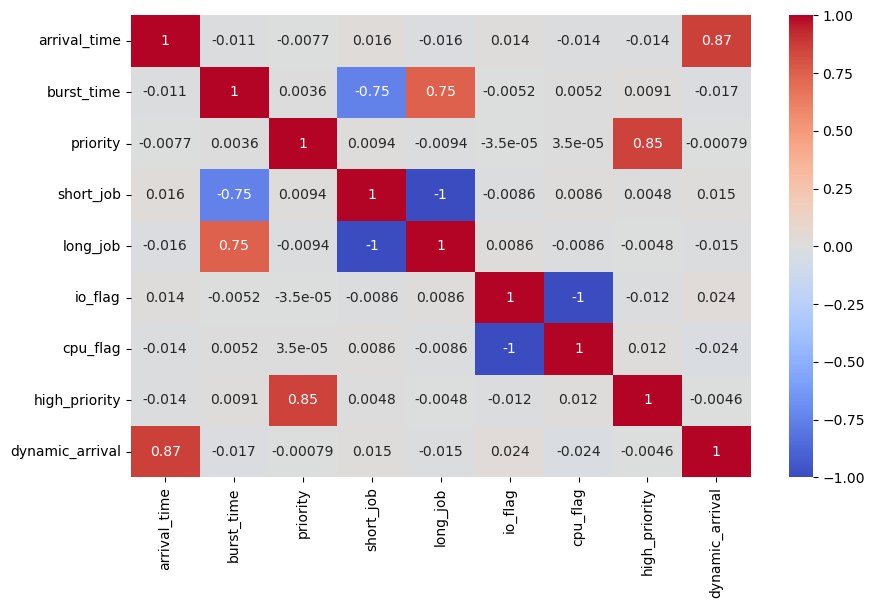

In [98]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')



In [99]:
df.drop(columns=['short_job','io_flag','long_job','cpu_flag','high_priority','dynamic_arrival'], axis=1, inplace=True)

In [100]:
# New features
df['burst_priority_ratio'] = df['burst_time'] / (df['priority'] + 1)
# df['is_short'] = (df['burst_time'] < 6).astype(int)
# df['is_late'] = (df['arrival_time'] > 10).astype(int)

In [101]:
df['interaction_1'] = df['burst_time'] * df['priority']
df['interaction_2'] = df['arrival_time'] * df['burst_time']

In [102]:
cat_col=[]
num_col=[]
for col in df.columns:
    if df[col].dtype == 'object':
        cat_col.append(col)
    else:
        num_col.append(col)

In [103]:
num_col

['arrival_time',
 'burst_time',
 'priority',
 'burst_priority_ratio',
 'interaction_1',
 'interaction_2']

In [104]:
cat_col

['process_type', 'best_algorithm']

In [105]:
df.columns

Index(['arrival_time', 'burst_time', 'priority', 'process_type',
       'best_algorithm', 'burst_priority_ratio', 'interaction_1',
       'interaction_2'],
      dtype='object')

<Axes: >

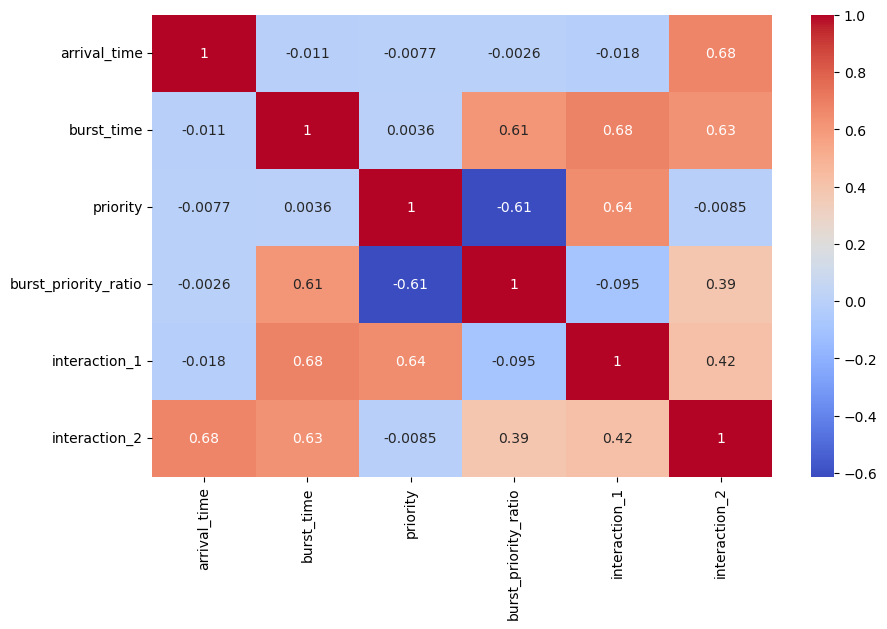

In [106]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_col].corr(), annot=True, cmap='coolwarm')



In [107]:
df.to_csv("../data/cleaned_cpu_scheduling_process.csv", index=False)